M1-M4 are the assumed models. M1-M12 are observation data-generating processes.

DeepSet, `S=D`, 10 observations. Use the previously trained 20d/10n networks.
Sparse OOD data: for M5-M12, only the first `1` dimensions follow the source-model setting; the remaining dimensions follow M1.
This notebook uses l2 summary distance by default and writes to a sparse-specific result directory.


In [1]:
import pickle
from pathlib import Path

import bayesflow as bf
import keras
import numpy as np
import pandas as pd

from benchmark.examples.gaussian.datasets.datasets import GetDatasets
from benchmark.examples.gaussian.datasets.calculation import Calculation
from benchmark.examples.gaussian.analysis import summry_diagnostic as sd
sd.quiet_bayesflow_progress()

INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/anaconda3/envs/benchmark2/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
INFO:bayesflow:Using backend 'jax'


In [2]:
RNG = np.random.default_rng(2025)
num_dims = 20
num_obs = 10
num_datasets = 50
num_samples = 1000
n_ref = 2000

# Change this to 5 for the five-dimensional sparse misspecification experiment.
sparse_dims = 1
sparse_indices = np.arange(sparse_dims)
sparse_sources = tuple(f"m{i}" for i in range(5, 13))
distance_metric = "l2"

project_dir = Path("/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian")
network_dir = project_dir / "networks"
result_tag = f"20d_10n_sparse{sparse_dims}_{distance_metric}"
result_dir = project_dir / "results" / f"ood_{result_tag}"
dataset_dir = result_dir / "datasets"
figure_dir = result_dir / "figures"

source_specs = {
    "m1": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m2": {"mu_prior_mean": 3.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m3": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 3.0},
    "m4": {"mu_prior_mean": 0.1, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m5": {"mu_prior_mean": 1.5, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m6": {"mu_prior_mean": 5.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m7": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 5.0},
    "m8": {"mu_prior_mean": 0.0, "mu_prior_std": 3.0, "likelihood_std": 1.0},
    "m9": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 0.1},
    "m10": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 0.01},
    "m11": {"mu_prior_mean": 0.0, "mu_prior_std": 0.1, "likelihood_std": 1.0},
    "m12": {"mu_prior_mean": 0.0, "mu_prior_std": 0.01, "likelihood_std": 1.0},
}
assumed_specs = {key: source_specs[key] for key in sd.ASSUMED_MODELS}
base_spec = source_specs["m1"]

print("result_dir:", result_dir)
print("sparse_dims:", sparse_dims)
print("sparse_sources:", sparse_sources)

result_dir: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/results/ood_20d_10n_sparse1_l2
sparse_dims: 1
sparse_sources: ('m5', 'm6', 'm7', 'm8', 'm9', 'm10', 'm11', 'm12')


In [3]:
def save_pickle(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("wb") as file:
        pickle.dump(obj, file)


def load_pickle(path):
    with Path(path).open("rb") as file:
        return pickle.load(file)

In [4]:
# get datasets
logmlpmp_dataset_dir=project_dir / "results" / "ood_20d_10n_sparse1_linf"/"datasets"
datasets = {source: load_pickle(logmlpmp_dataset_dir / f"{source}_logml_pmp.pkl") for source in sd.SOURCE_MODELS}

In [5]:
# Load trained approximators
filepath_m1 = network_dir / "m1_s_20d_10n.keras"
filepath_m2 = network_dir / "m2_s_20d_10n.keras"
filepath_m3 = network_dir / "m3_s_20d_10n.keras"
filepath_m4 = network_dir / "m4_s_20d_10n.keras"
filepath_direct = network_dir / "direct_s_20d_10n.keras"

approximator_m1 = keras.saving.load_model(filepath_m1)
approximator_m2 = keras.saving.load_model(filepath_m2)
approximator_m3 = keras.saving.load_model(filepath_m3)
approximator_m4 = keras.saving.load_model(filepath_m4)

approximator_direct = keras.saving.load_model(filepath_direct)

approximators = {"m1": approximator_m1, "m2": approximator_m2, "m3": approximator_m3, "m4": approximator_m4}

In [6]:
# Fit summary-space reference distributions under the assumed models.
# These simulators stay unchanged because the neural networks and assumed models are unchanged.
def make_simulator(spec, seed):
    rng = np.random.default_rng(seed)

    def prior():
        mu = rng.normal(loc=spec["mu_prior_mean"], scale=spec["mu_prior_std"], size=num_dims)
        return {"mu": mu}

    def likelihood(mu):
        x = rng.normal(loc=mu, scale=spec["likelihood_std"], size=(num_obs, num_dims))
        return {"x": x}

    return bf.make_simulator([prior, likelihood])


simulators = {
    assumed: make_simulator(assumed_specs[assumed], 3025 + i)
    for i, assumed in enumerate(sd.ASSUMED_MODELS)
}
references = sd.fit_summary_references(
    approximators,
    simulators,
    n_ref=n_ref,
    distance_metric=distance_metric,
    alpha=0.1,
)

pd.DataFrame({
    k: {
        "metric": v["distance_metric"],
        "summary_dim": v["summary_dim"],
        "dm_low": v["dm_low"],
        "dm_high": v["dm_high"],
        "median": v["median"],
        
    }
    for k, v in references.items()
}).T

,metric,summary_dim,dm_low,dm_high,median
m1,l2,20,0.688625,1.324814,0.963338
m2,l2,20,0.671891,1.335199,0.960233
m3,l2,20,0.736897,1.185308,0.952363
m4,l2,20,0.67521,1.33809,0.960102


In [7]:
# Add dynamic distance regimes and x(y) score.
datasets = sd.add_distances_and_regimes(datasets, approximators, references)

posterior_df = sd.collect_posterior_distance_frame(datasets, n_samples=1000)
logml_df = sd.collect_logml_distance_frame(datasets)
pmp_df = sd.collect_pmp_ambiguity_frame(datasets)
logml_summary, pmp_summary = sd.summarize_frames(logml_df, pmp_df)

result_dir.mkdir(parents=True, exist_ok=True)
posterior_df.to_csv(result_dir / f"posterior_distance_frame_{result_tag}.csv", index=False)
logml_df.to_csv(result_dir / f"logml_distance_frame_{result_tag}.csv", index=False)
pmp_df.to_csv(result_dir / f"pmp_ambiguity_frame_{result_tag}.csv", index=False)
logml_summary.to_csv(result_dir / f"logml_summary_{result_tag}.csv", index=False)
pmp_summary.to_csv(result_dir / f"pmp_summary_{result_tag}.csv", index=False)
for source, data in datasets.items():
    save_pickle(data, dataset_dir / f"{source}_processed_{result_tag}.pkl")

In [8]:
# # Load sparse datasets for plotting.
# datasets = {
#     source: load_pickle(dataset_dir / f"{source}_processed_{result_tag}.pkl")
#     for source in sd.SOURCE_MODELS
# }
# posterior_df = pd.read_csv(result_dir / f"posterior_distance_frame_{result_tag}.csv")
# logml_df = pd.read_csv(result_dir / f"logml_distance_frame_{result_tag}.csv")
# pmp_df = pd.read_csv(result_dir / f"pmp_ambiguity_frame_{result_tag}.csv")

## Plots

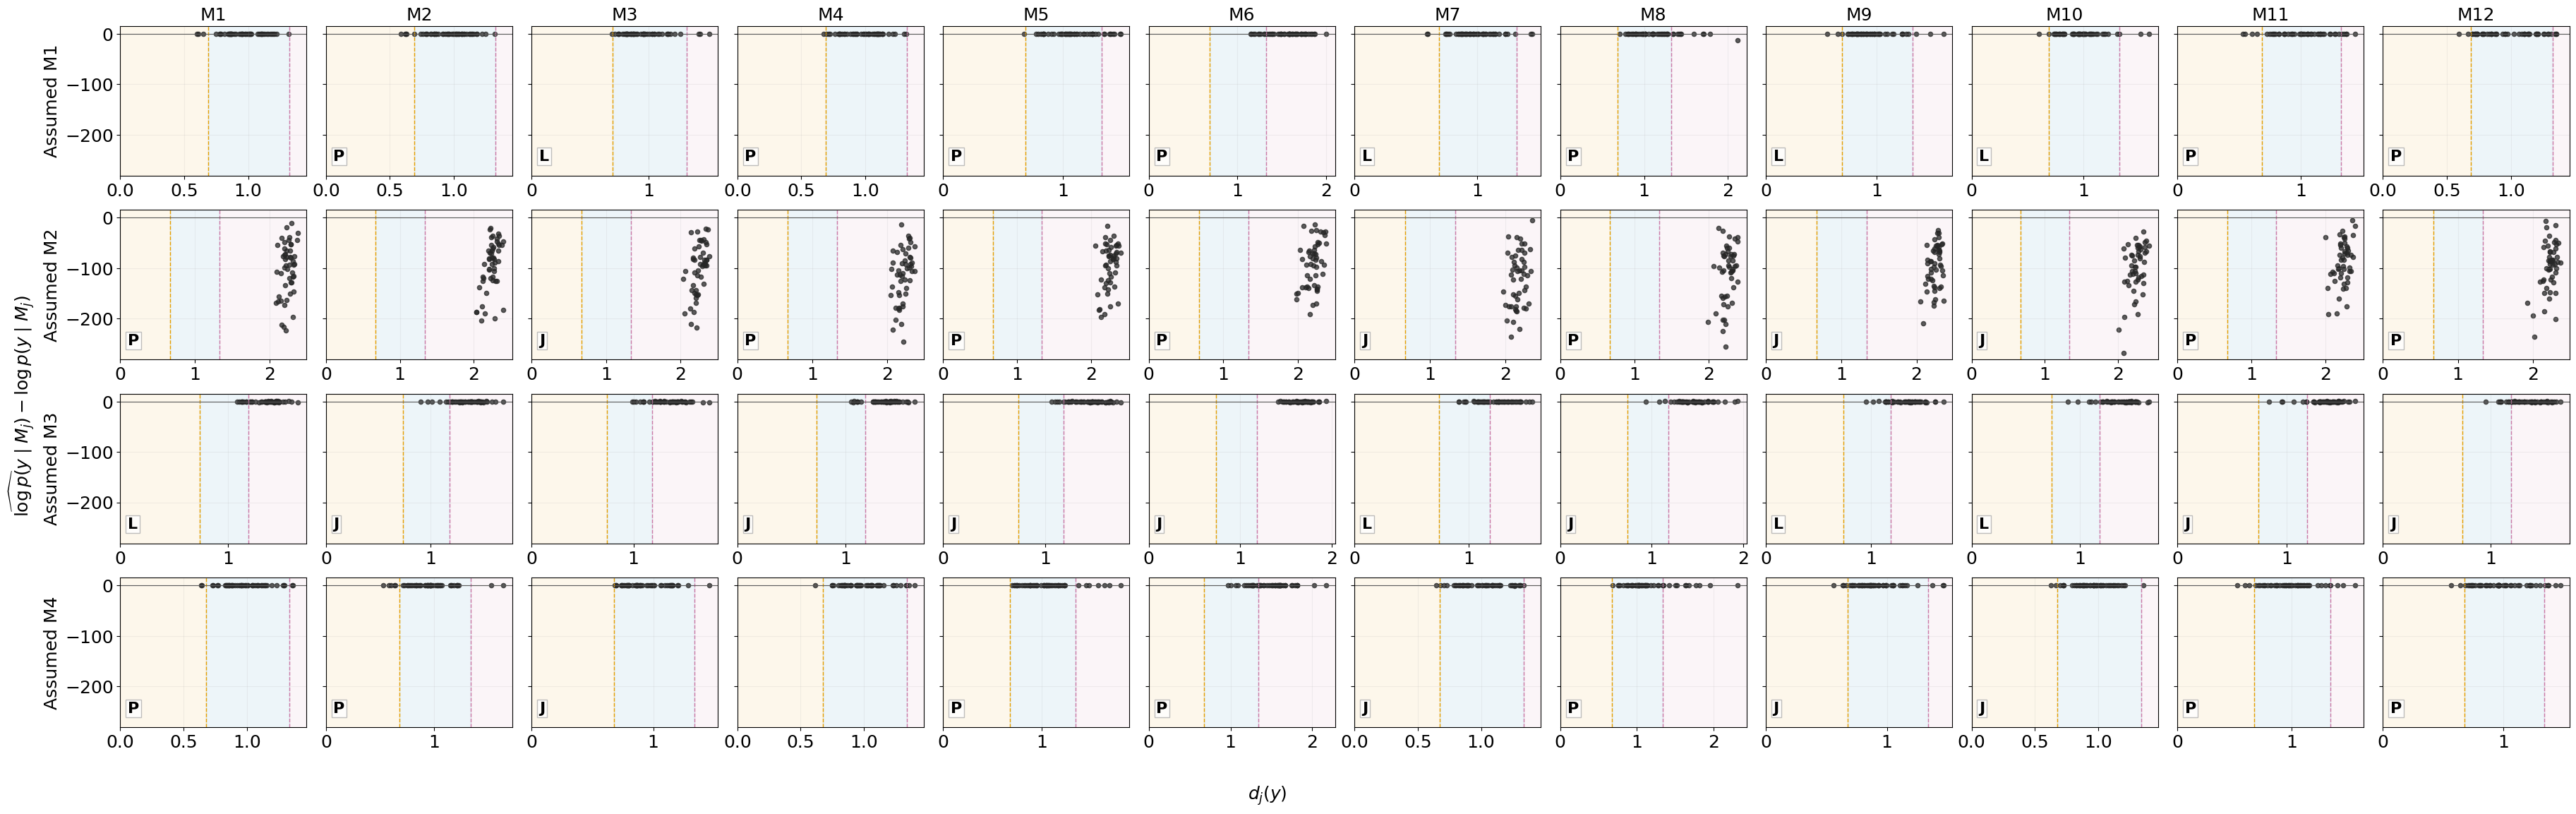

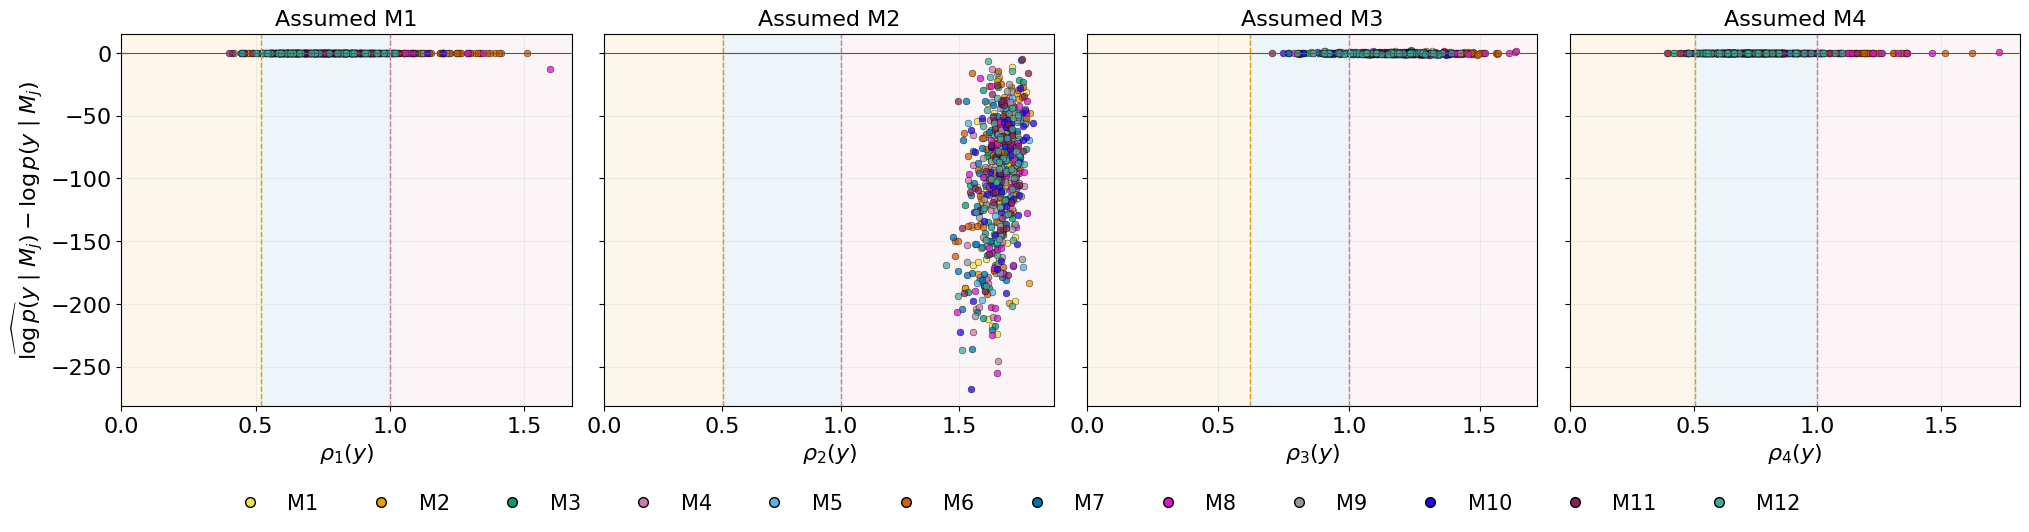

In [9]:
# signed logml error with shared y-axis
sd.plot_signed_logml_error_grid(logml_df, output_dir=figure_dir);
sd.plot_logml_error_vs_distance(logml_df, color_by="source", output_dir=figure_dir);
# sd.plot_logml_error_vs_distance(logml_df, color_by="gold_logml", output_dir=figure_dir);

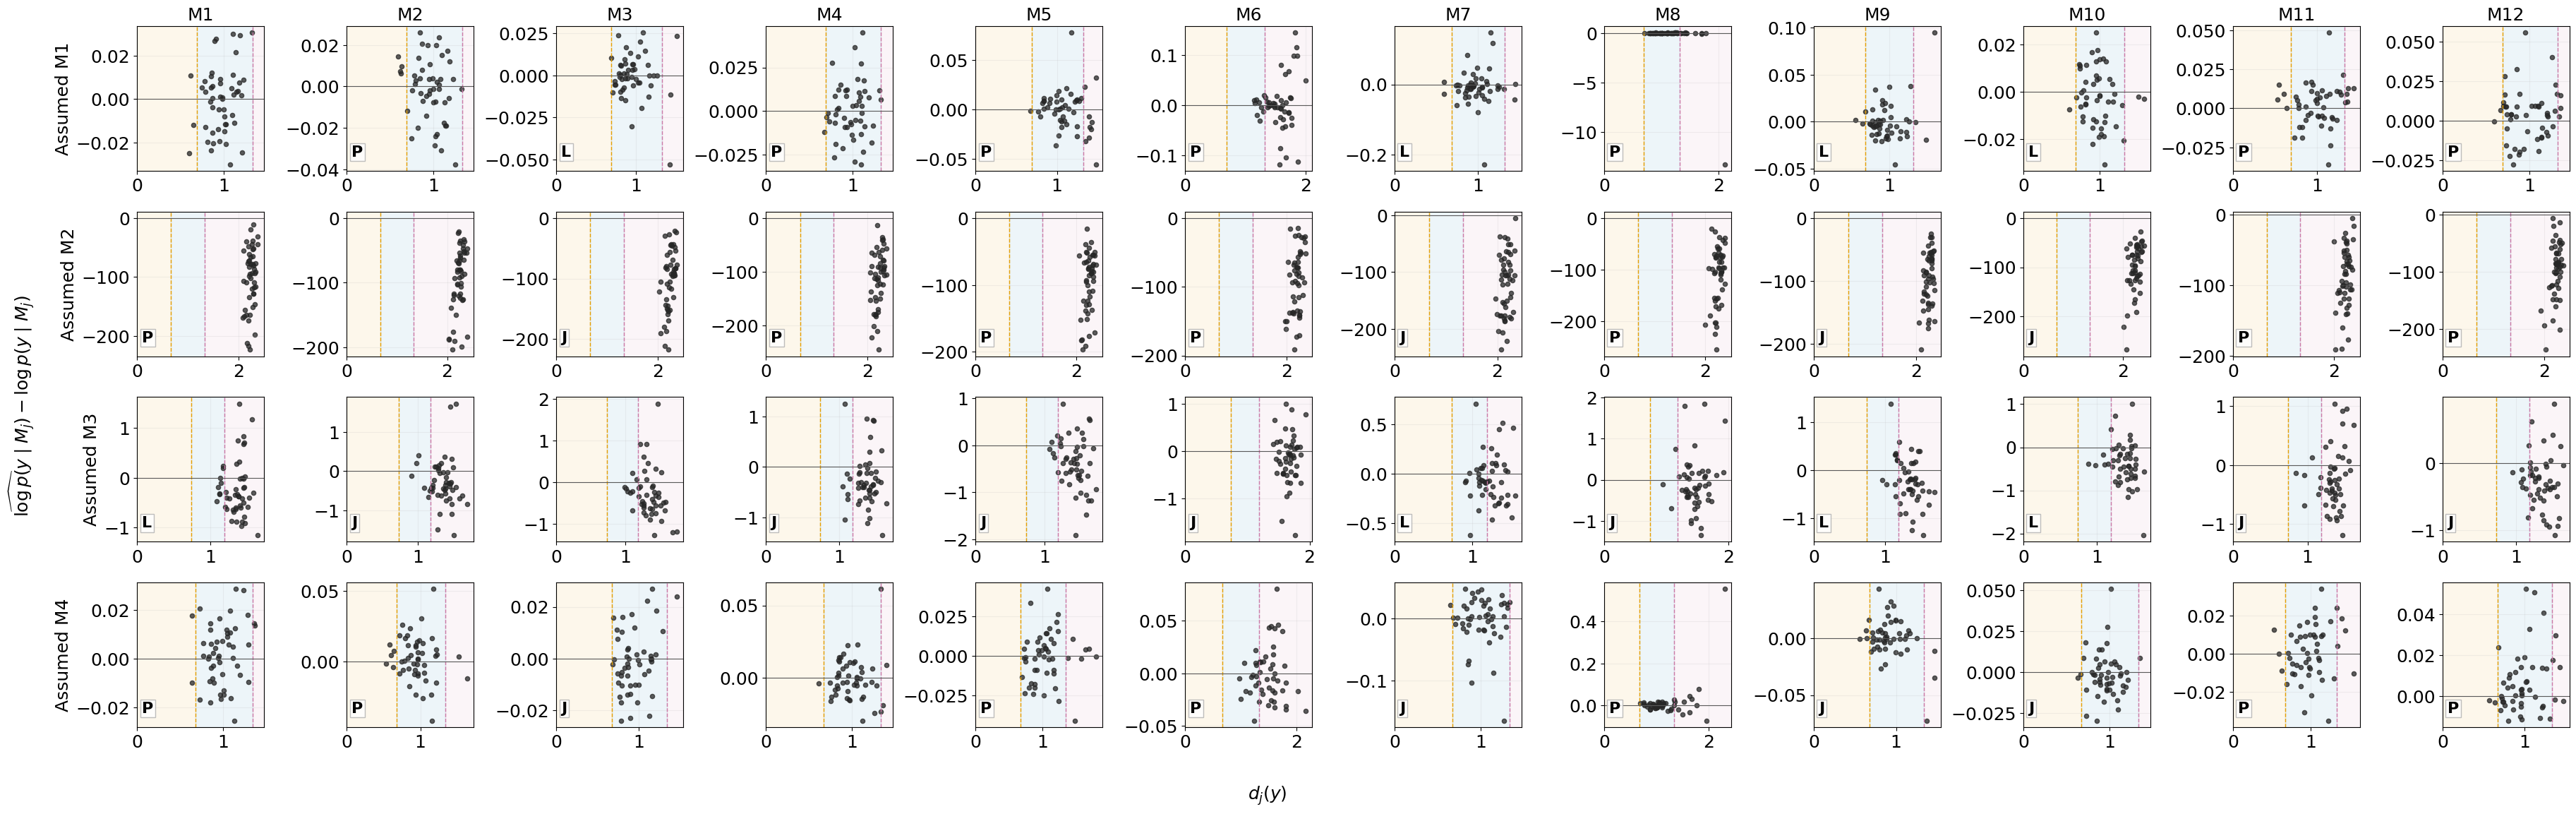

In [10]:
sd.plot_signed_logml_error_grid(logml_df, output_dir=figure_dir,sharey=False);

(<Figure size 1960x600 with 4 Axes>,
 array([<Axes: title={'center': '$p(M_1\\mid y)$'}, xlabel='$\\log(1+A(y))$', ylabel='$\\hat{p}(M_j|y)-p(M_j|y)$'>,
        <Axes: title={'center': '$p(M_2\\mid y)$'}, xlabel='$\\log(1+A(y))$'>,
        <Axes: title={'center': '$p(M_3\\mid y)$'}, xlabel='$\\log(1+A(y))$'>,
        <Axes: title={'center': '$p(M_4\\mid y)$'}, xlabel='$\\log(1+A(y))$'>],
       dtype=object))

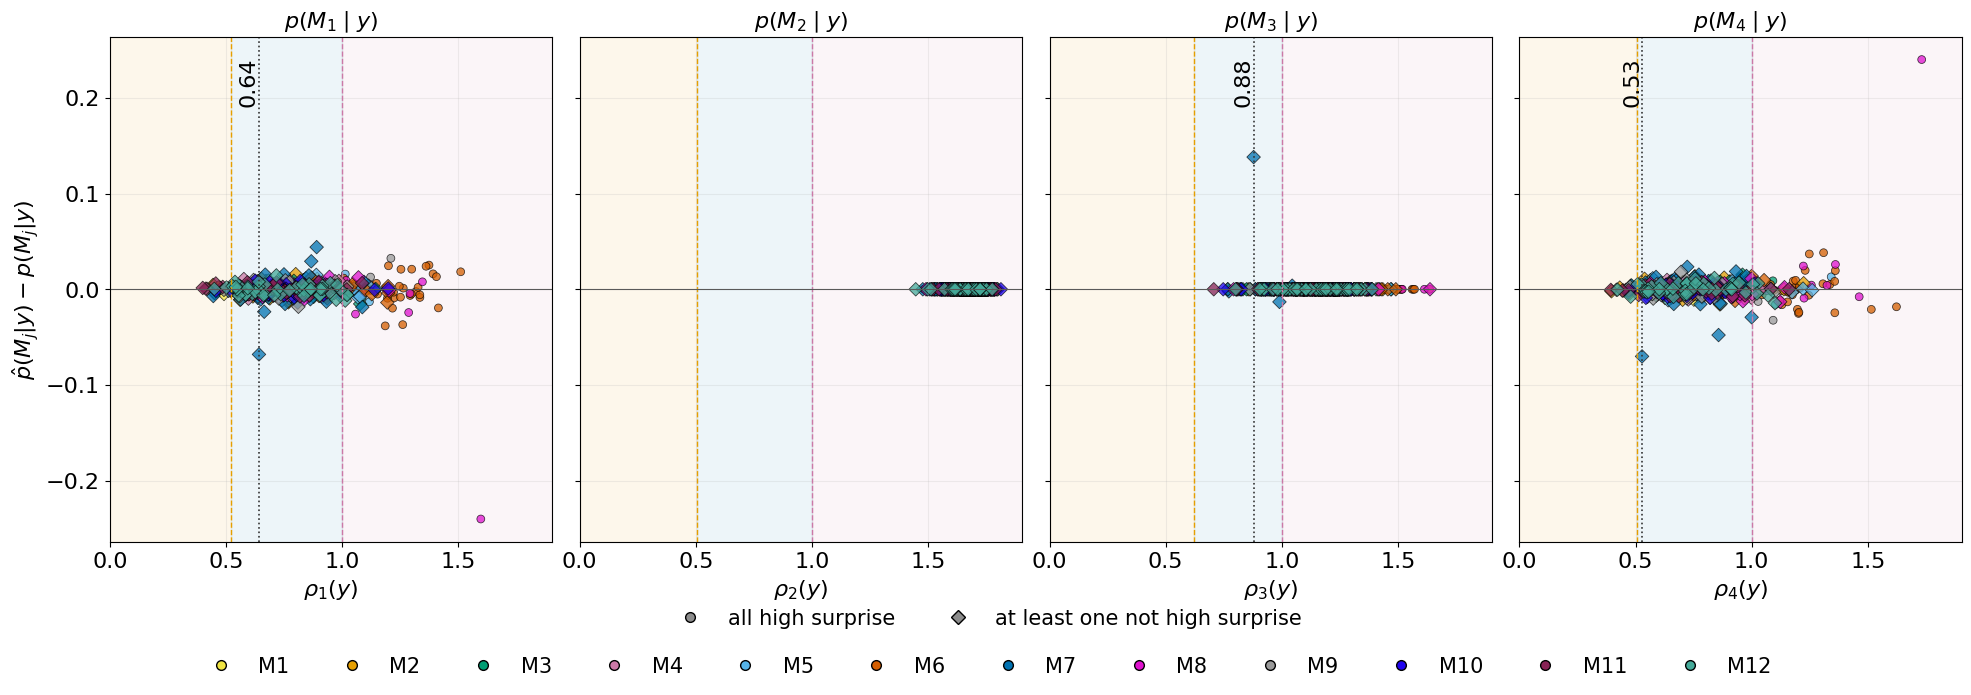

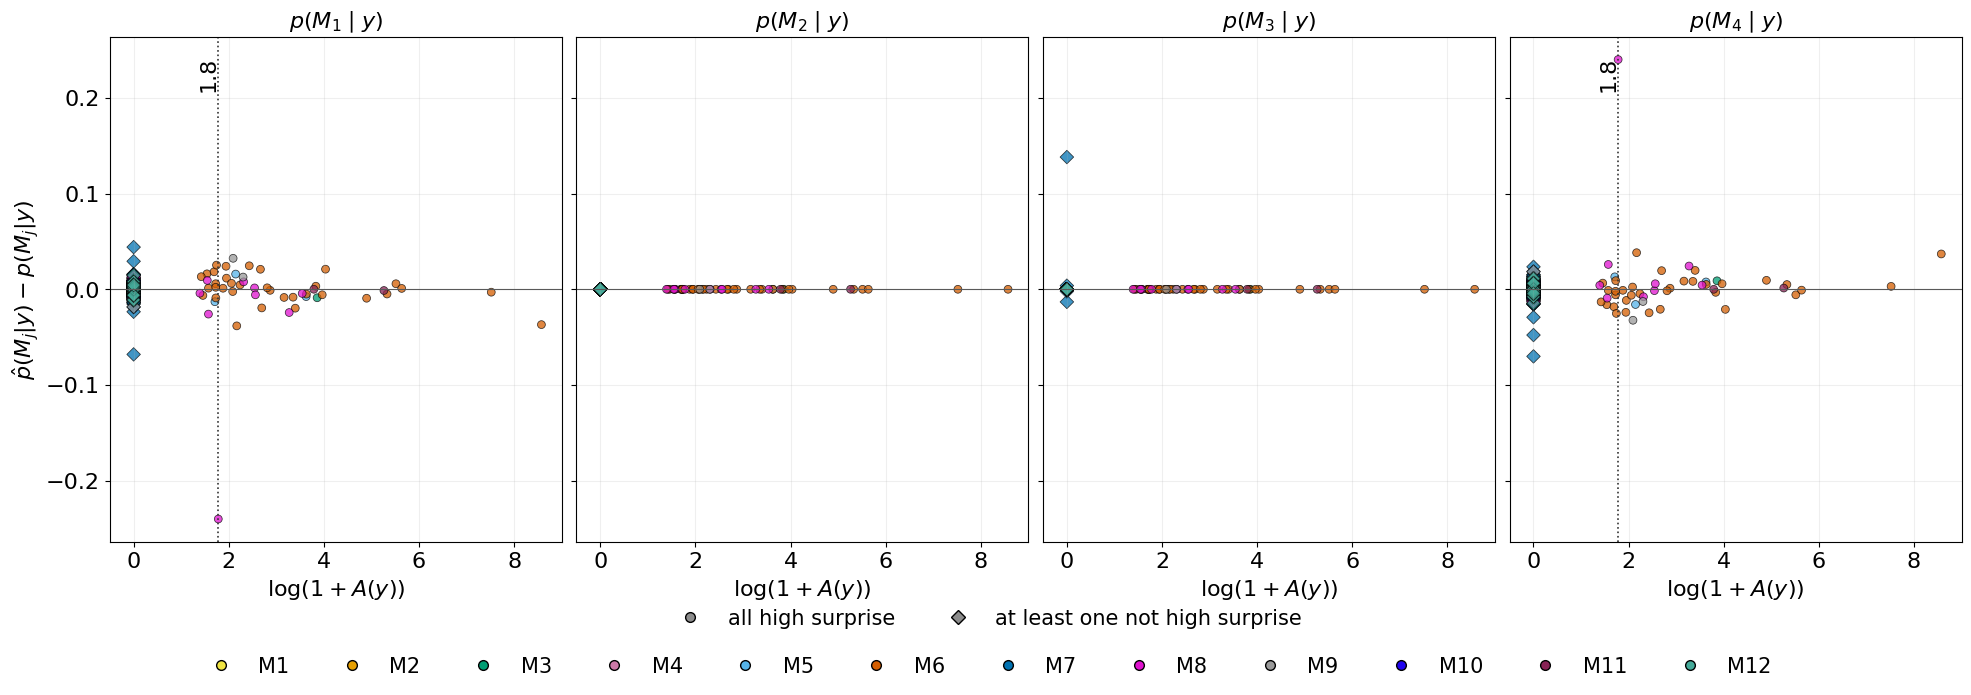

In [11]:
# PMP plots
sd.plot_pmp_diagnostic(pmp_df,x="rho",y="signed_error",group_by="global_extrapolation_source",estimate="npe",output_dir=None,regions="assumed",sharex=True,x_min=0.0,error_bound=0.05,)
sd.plot_pmp_diagnostic(pmp_df,x="logA",y="signed_error",group_by="global_extrapolation_source",estimate="npe",output_dir=figure_dir,filename="pmp_error_global_extrapolation_by_source.png",
                       sharex=True,error_bound=0.05,error_subset="all_extrapolative")


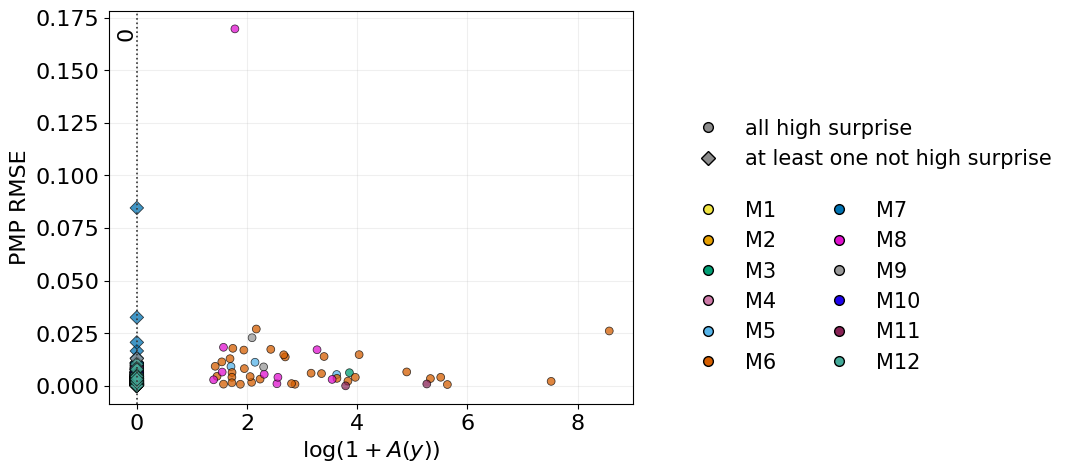

In [12]:
fig, ax = sd.plot_pmp_diagnostic(
    pmp_df,
    x="logA",
    y="rmse",
    group_by="global_extrapolation_source",
    estimate="npe",
    output_dir=None,
    sharex=True,
    x_min=-0.5,
    error_bound=0.05,
)

In [13]:
# # PMP estimates (NPE and NPMP) vs distance for each source model
# for source in sd.SOURCE_MODELS:
#     sd.plot_pmp_estimates_vs_distance(pmp_df, source,output_dir=figure_dir)

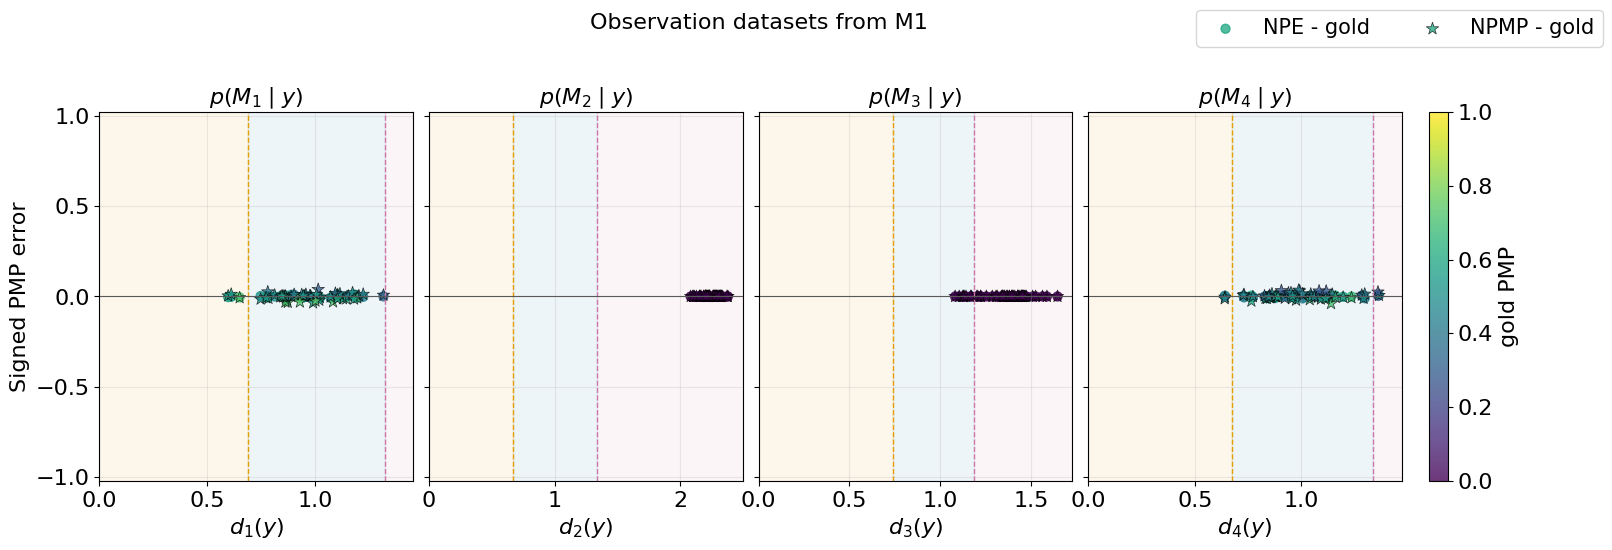

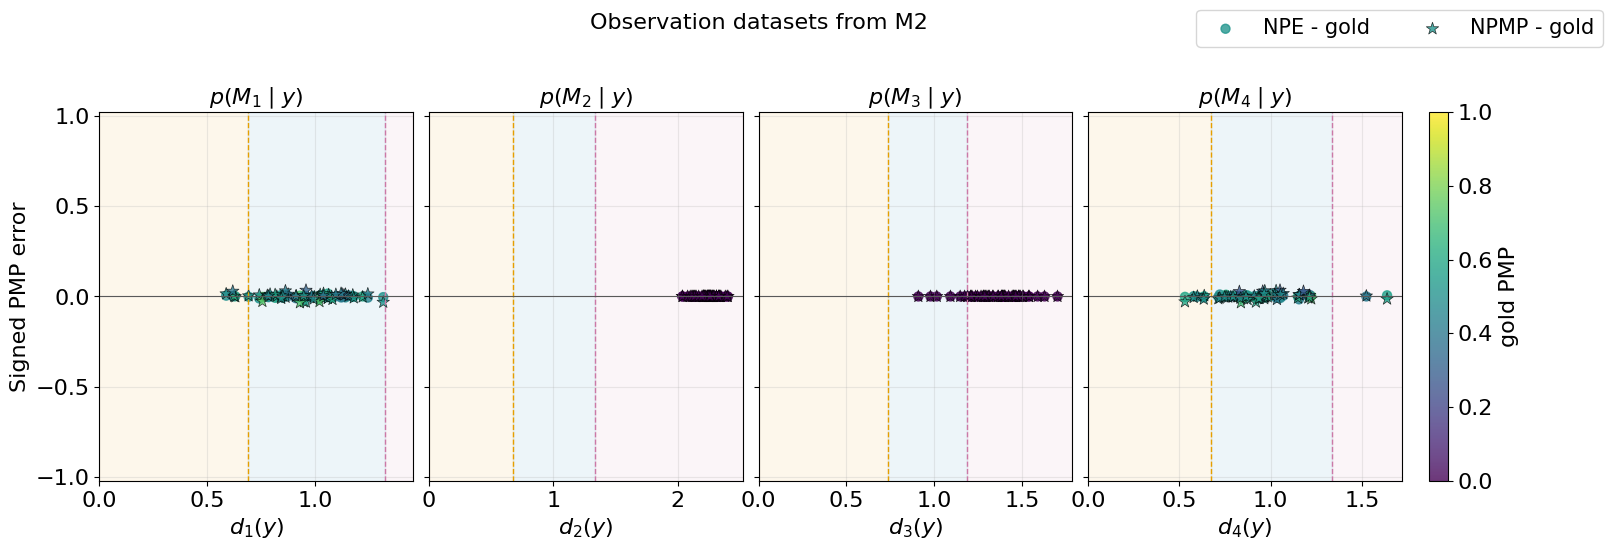

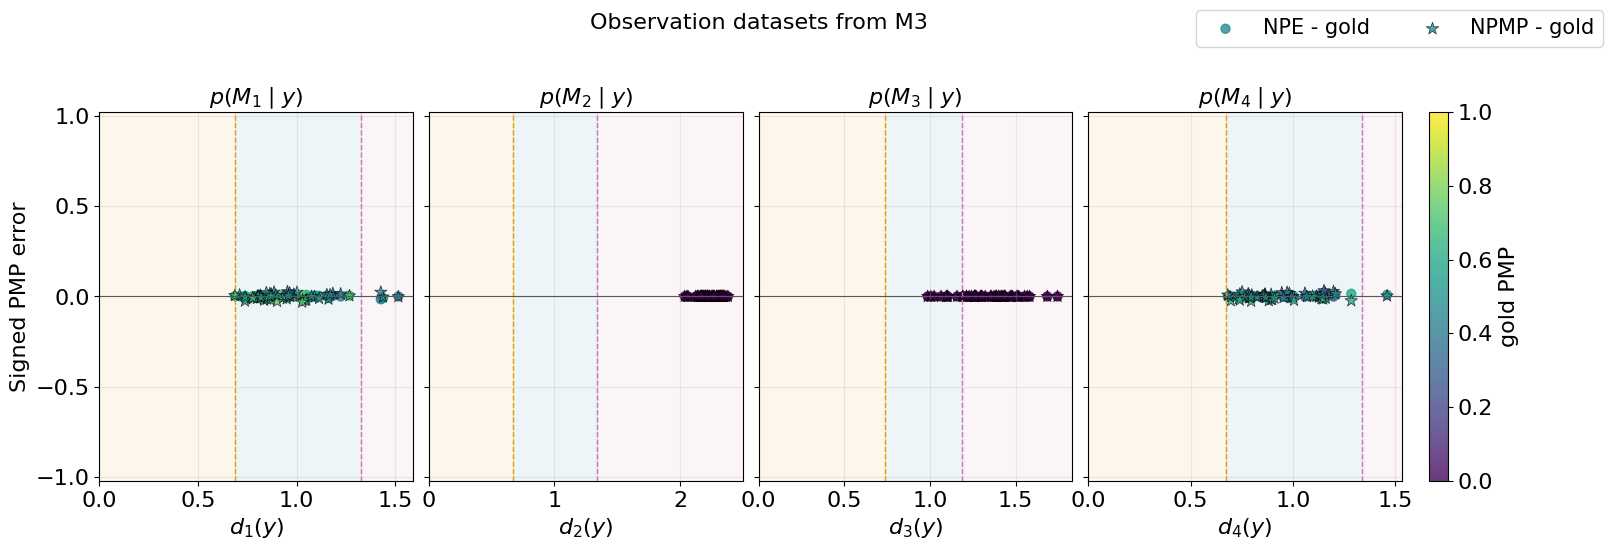

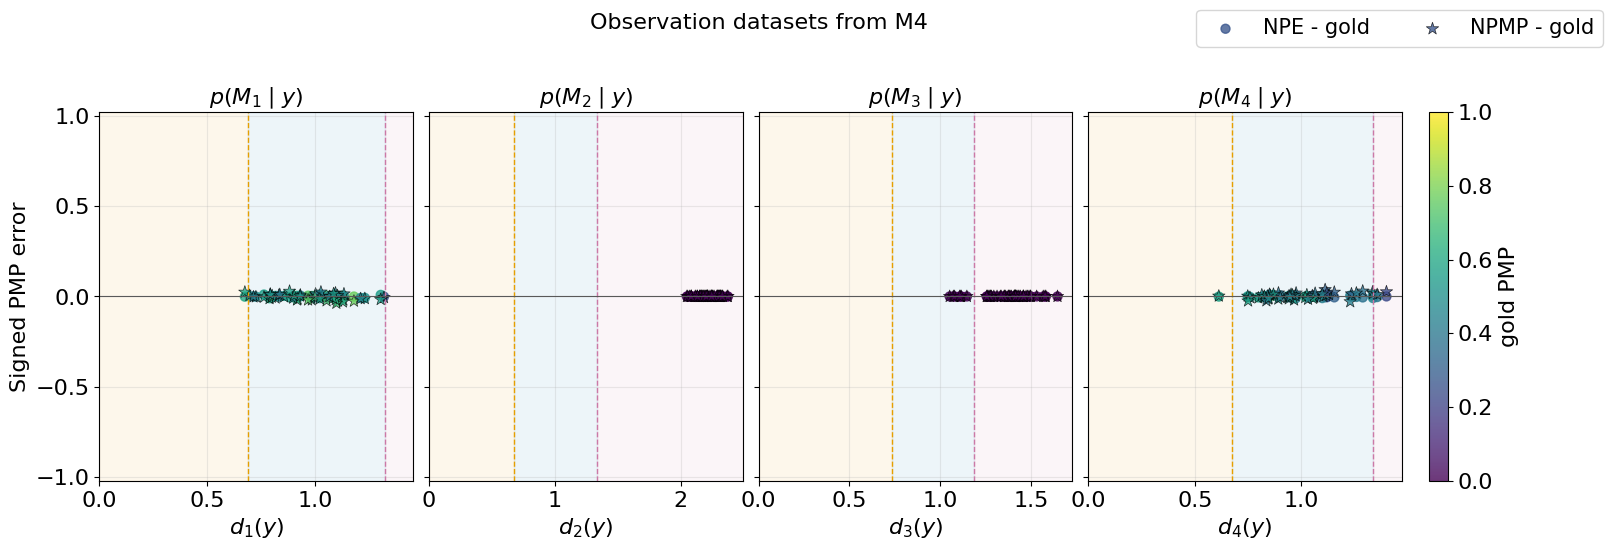

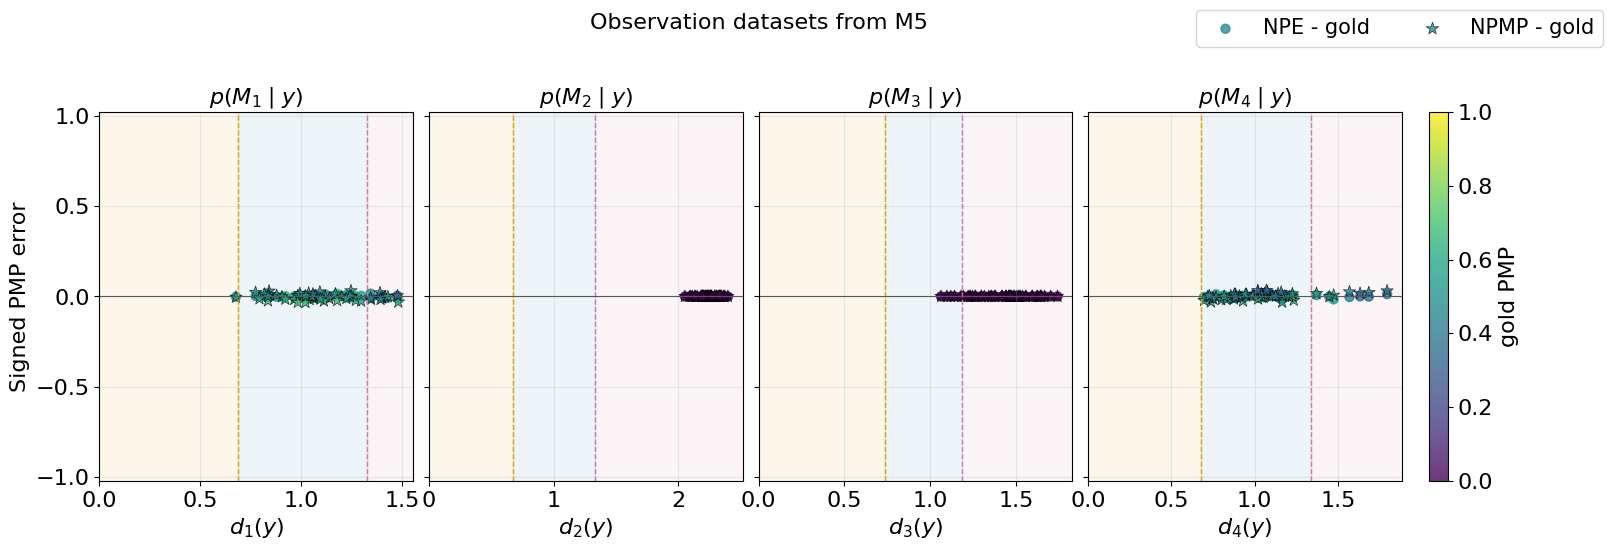

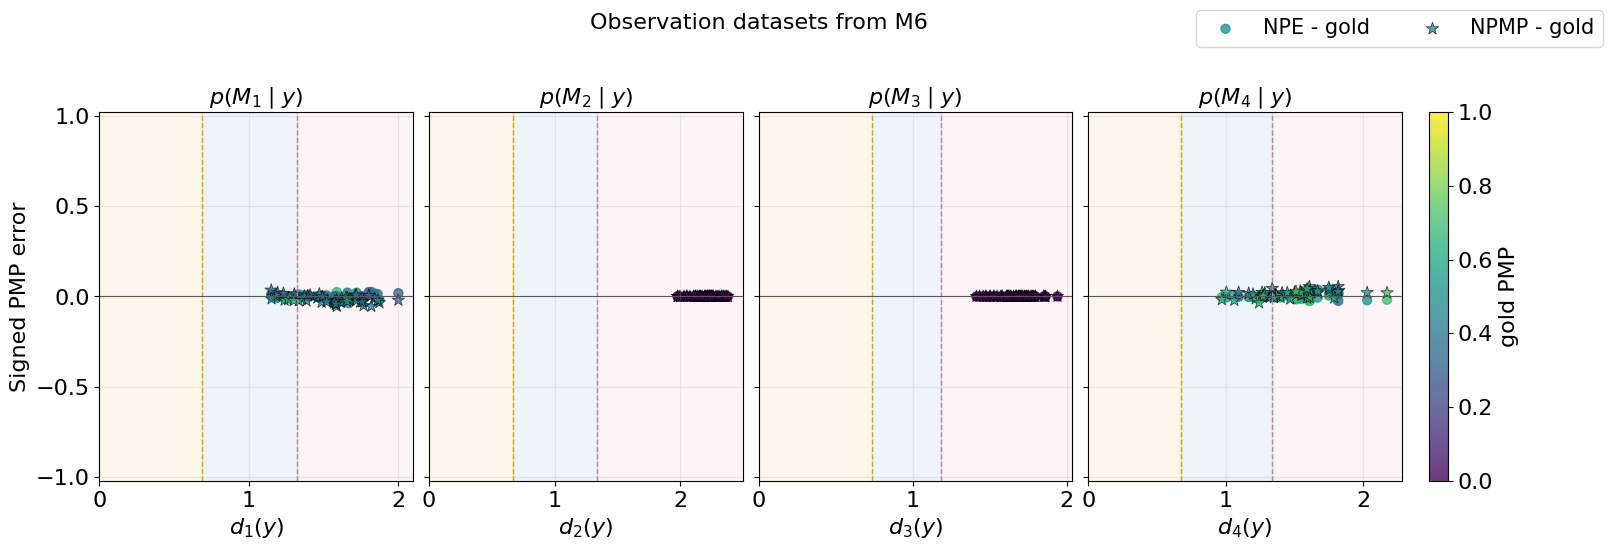

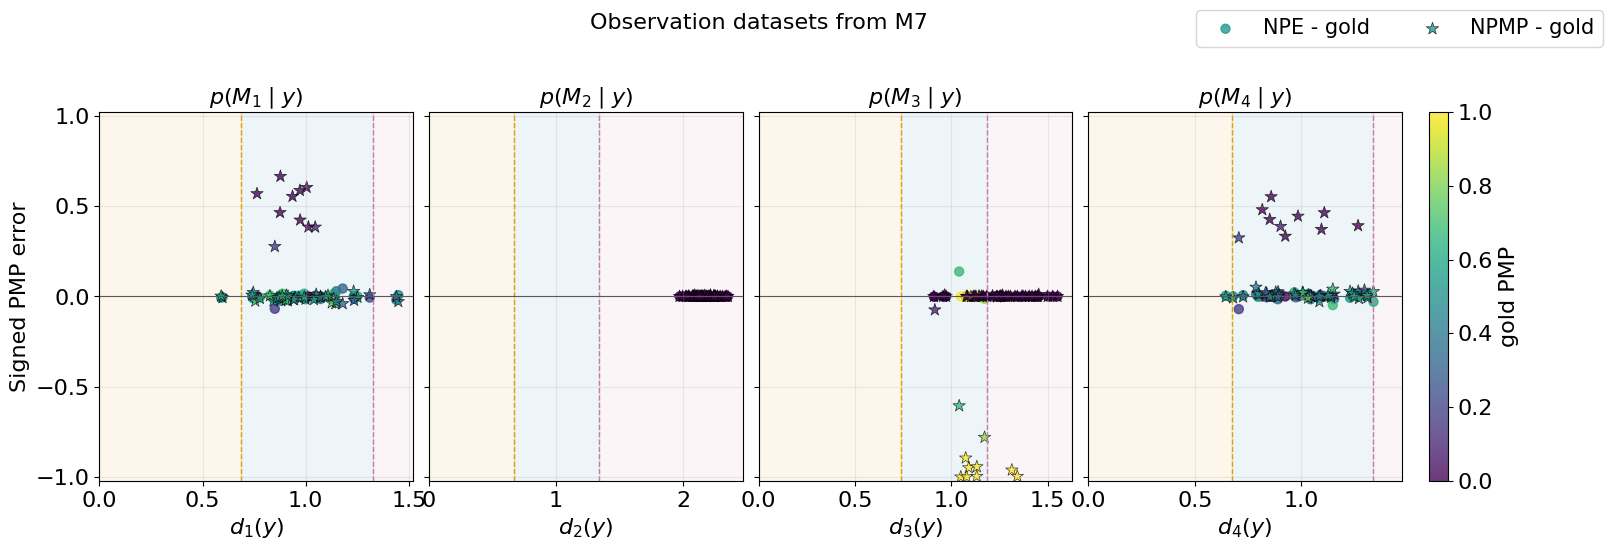

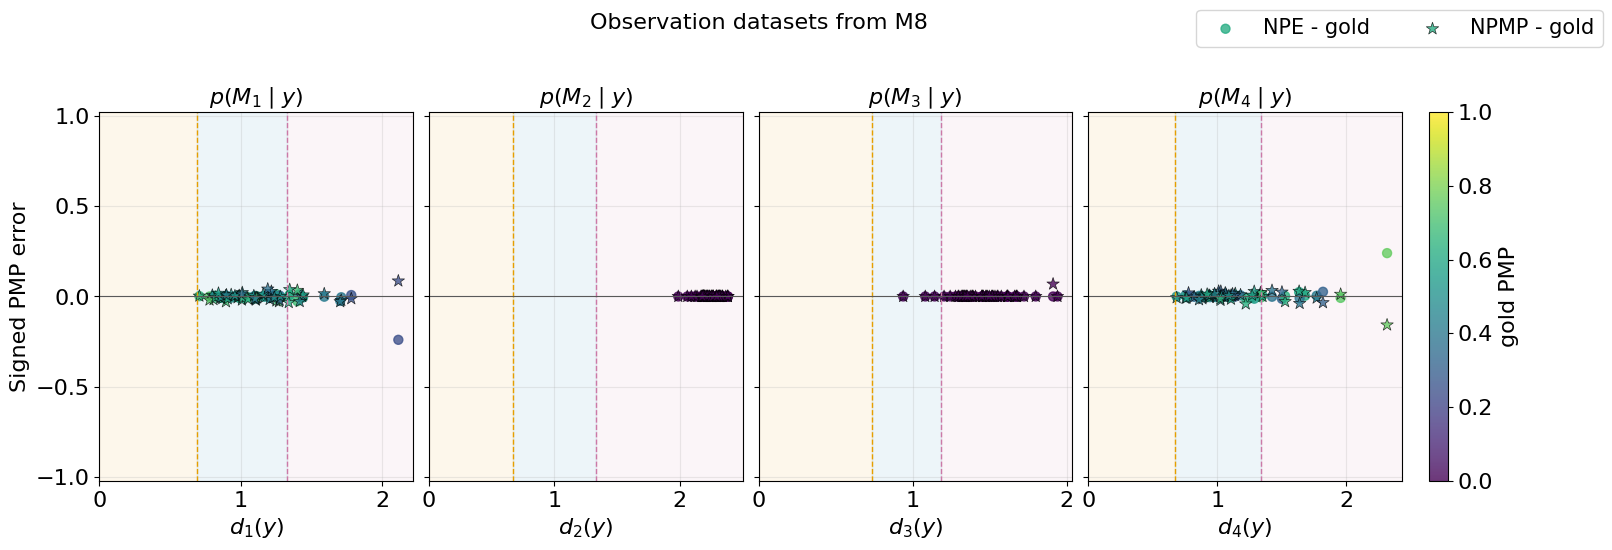

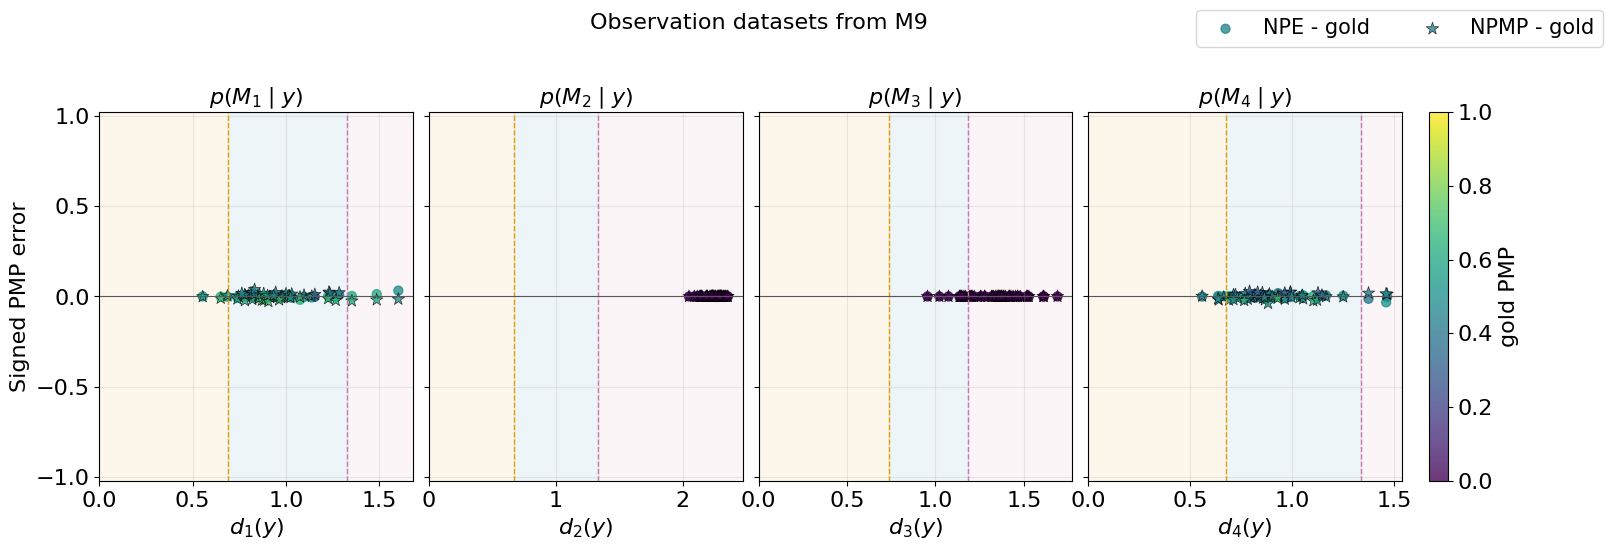

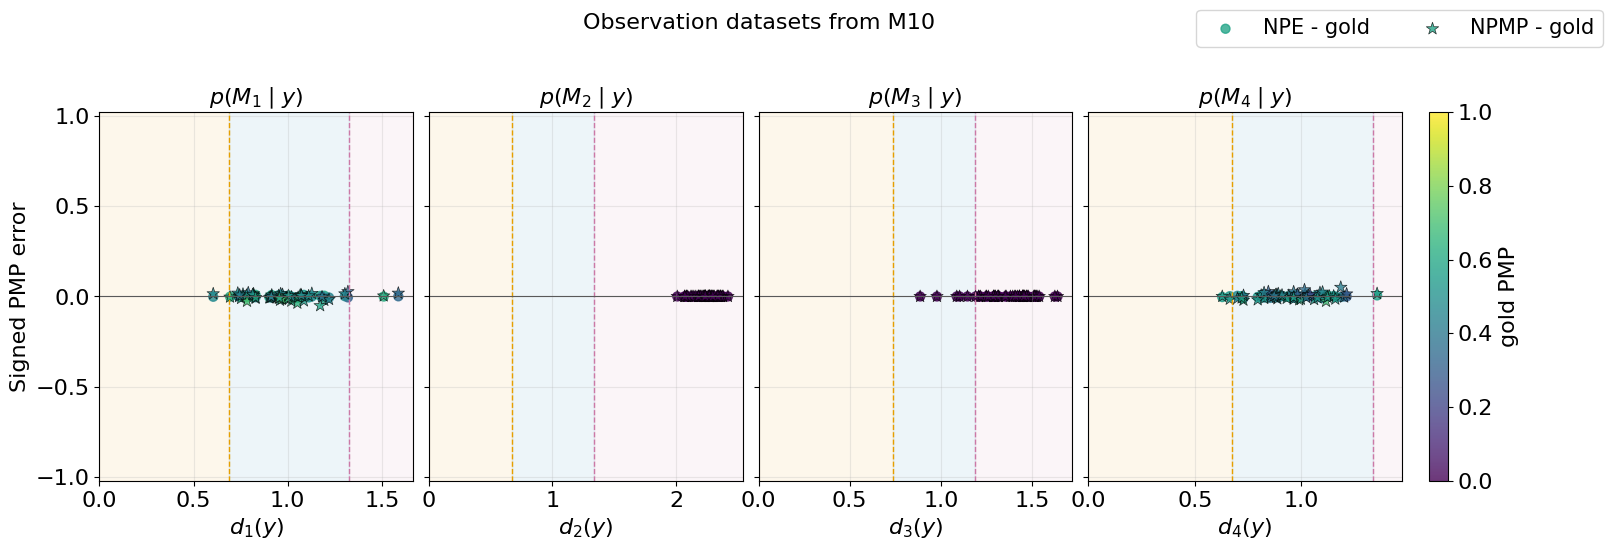

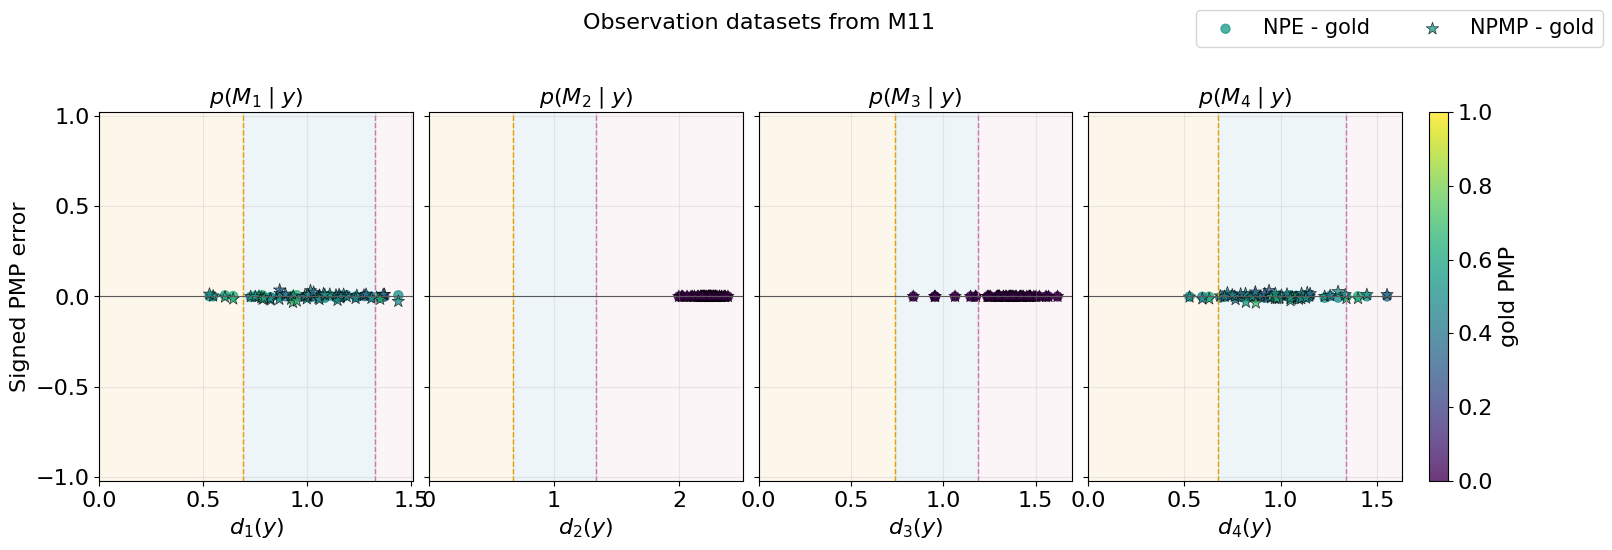

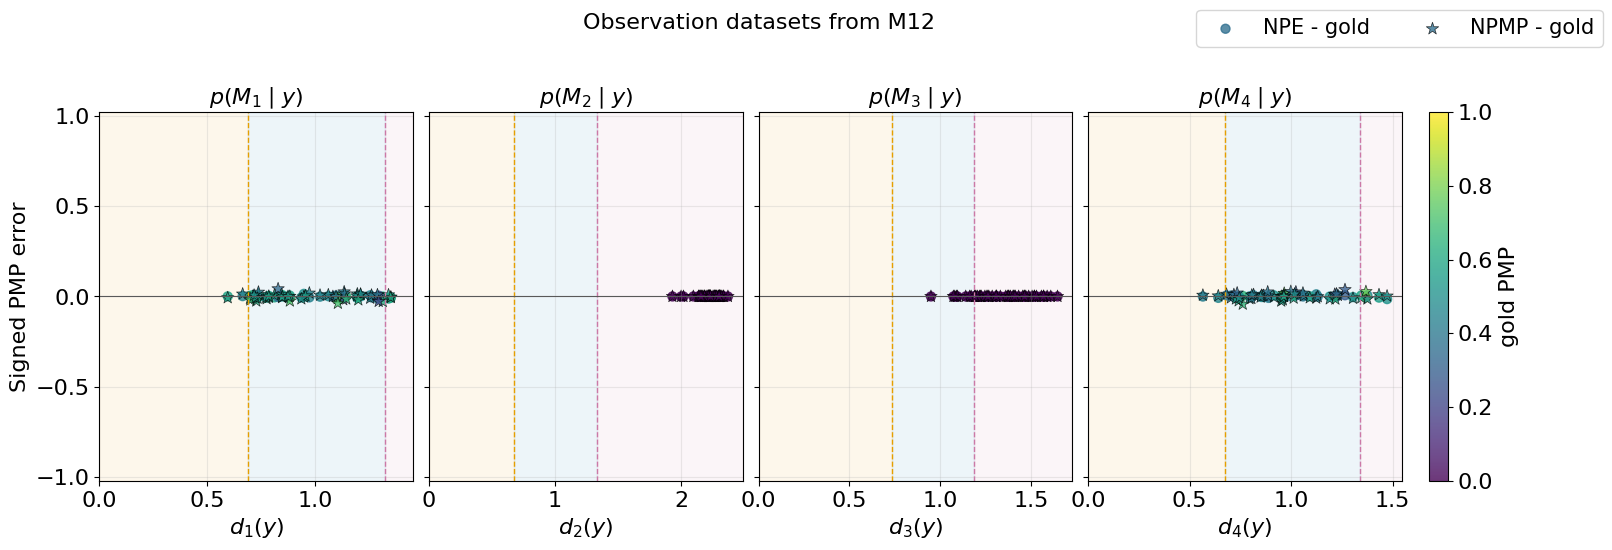

In [14]:
# PMP estimates (NPE and NPMP) vs distance for each source model
for source in sd.SOURCE_MODELS:
    sd.plot_pmp_estimates_vs_distance(pmp_df, source,x="distance",y="signed_error",output_dir=figure_dir)